In [1]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from lcdb.db import LCDB, ResultSet
from lcdb.db._learning_curves import LearningCurve

import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

# load sklearn regressors
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.model_selection import ShuffleSplit, train_test_split, cross_validate
from sklearn.metrics import get_scorer

# Get Data For Surrogate

In [2]:
def load_workflow_results(wf: str, data_dir: Path) -> ResultSet:
    f = data_dir / f"{wf}.jsonl"
    if not f.exists():
        print(f"[WARN] Missing JSONL for workflow: {wf} (expected {f})")
        return None
    rs = ResultSet.read_jsonl(f)
    return rs

In [3]:
rs_liblinear = load_workflow_results("lcdb.workflow.sklearn.LibLinearWorkflow", Path("../data"))
rs_knn = load_workflow_results("lcdb.workflow.sklearn.KNNWorkflow", Path("../data"))
print(rs_knn.datasets)

[WARN] Missing JSONL for workflow: lcdb.workflow.sklearn.LibLinearWorkflow (expected ../data/lcdb.workflow.sklearn.LibLinearWorkflow.jsonl)
{3, 12, 54, 23, 31}


# Train Surrogate

In [23]:
class SurrogateBuilder:

    def __init__(self, rs, ignore_nan_values=True, allow_preprocessed_pipelines=True):
        if len(rs.workflows) != 1:
            raise ValueError(f"ResultSet must contain exactly one workflow but has these: {rs.workflows}.")
        self.workflow = sorted(rs.workflows)[0]

        if len(rs.datasets) != 1:
            raise ValueError(f"ResultSet must contain exactly one dataset but has these: {rs.datasets}.")
        self.openmlid = sorted(rs.datasets)[0]
    
        # create rows based on mean curve on validation error rate
        rows = []
        self.allow_preprocessed_pipelines = allow_preprocessed_pipelines
        for result in rs:
            x = result["config"].copy()
            
            # cut out curves with non-standard preprocessing if not allowed
            if not allow_preprocessed_pipelines:
                if x["pp@cat_encoder"] != 'ordinal' or x["pp@decomposition"] != "none" or x["pp@featureselector"] != "none" or x["pp@scaler"] != "none" or x["pp@featuregen"] != "none":
                    continue
                for col in [c for c in x.keys() if c.startswith("pp@")]:
                    del x[col]

            lc = LearningCurve.from_json(result["learning_curve"])
            val_error_rate_curves = lc.values[0, 1]
            for anchor, mean_val in zip(lc.anchors_size, val_error_rate_curves.mean(axis=(0, 1, 2))):
                if np.isnan(mean_val) and ignore_nan_values:
                    continue
                x_at_anchor = x.copy()
                x_at_anchor["anchor"] = anchor
                x_at_anchor["score"] = mean_val
                rows.append(x_at_anchor)
        self.df = pd.DataFrame(rows)
    
    @property
    def anchors_in_original_data(self):
        return sorted(self.df["anchor"].unique())

    def get_standard_pipeline_for_model(self, model):
        """
        Create an sklearn Pipeline that applies:
        - OneHotEncoder to categorical columns
        - StandardScaler to numerical columns
        - model as the final estimator

        Parameters
        ----------
        model : sklearn estimator
            The model to be trained (e.g. LogisticRegression, RandomForestClassifier).
        dtypes : pandas.Series
            Column dtypes, typically X.dtypes.

        Returns
        -------
        sklearn.pipeline.Pipeline
        """

        if self.df is None:
            raise ValueError("Dataframe is not prepared. Call prepare_data() first.")
        dtypes = self.df.dtypes
        if not isinstance(dtypes, pd.Series):
            raise TypeError("dtypes must be a pandas Series (e.g., X.dtypes)")

        categorical_features = dtypes[dtypes == "object"].index.tolist()
        numeric_features = dtypes[dtypes != "object"].index.tolist()
        numeric_features.remove("score")

        preprocessor = ColumnTransformer(
            transformers=[
                #("num", StandardScaler(), numeric_features),
                ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
            ],
            remainder="passthrough"
        )

        pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("model", model),
            ]
        )

        return pipeline

    def get_learning_surrogate_learning_curve(self, model_name, model, fixed_anchor=None, test_points=100, splits_per_anchor=5, schedule=None):

        # check whether we have the file
        filename = f"surrogate_lcs/{self.workflow}/{model_name}_{self.openmlid}_pp{self.allow_preprocessed_pipelines}_anchor{fixed_anchor}_{test_points}tp.json"

        # read from cache if possible
        path = Path(filename)

        # write results to cache
        if not path.exists():
        
            df = self.df.copy()
            if fixed_anchor is not None:
                df = df[df["anchor"] == fixed_anchor]

            # define standard schedule
            max_possible_num_training_points = len(df) - test_points
            if schedule is None:
                schedule = sorted(set([int(np.ceil(2**(i / 2))) for i in range(10, int(np.ceil(2 * np.log2(max_possible_num_training_points))))]))
                if max(schedule) < max_possible_num_training_points:
                    schedule.append(max_possible_num_training_points)
            
            if max(schedule) > max_possible_num_training_points:
                    raise ValueError(f"Not enough data points for the largest anchor in the schedule. Maximum number of  training points should be {max_possible_num_training_points}, but the schedule asks for (up to) {max(schedule)}.")
            
            # extract data
            X = df.drop(columns=["score"])
            y = df["score"].values

            # build learning curve
            train_lc_pairs = []
            val_lc_pairs = []
            pbar = tqdm(total = len(schedule) * splits_per_anchor)
            for anchor in schedule:
                train_lc_pairs_at_anchor = []
                val_lc_pairs_at_anchor = []

                for i_train, i_test in ShuffleSplit(n_splits=splits_per_anchor, train_size=anchor, test_size=test_points).split(X):
                    model.fit(X.iloc[i_train], y[i_train])
                    
                    # add train curve entry
                    y_true = y[i_train]
                    y_pred = model.predict(X.iloc[i_train])
                    train_lc_pairs_at_anchor.append([list(y_true), list(y_pred)])

                    # add validation curve entry
                    y_true = y[i_test]
                    y_pred = model.predict(X.iloc[i_test])
                    val_lc_pairs_at_anchor.append([list(y_true), list(y_pred)])

                    pbar.update(1)

                train_lc_pairs.append(train_lc_pairs_at_anchor)
                val_lc_pairs.append(val_lc_pairs_at_anchor)
            pbar.close()

            # write results to file
            path.parent.mkdir(parents=True, exist_ok=True)
            with open(filename, "w") as f:
                json.dump((schedule, train_lc_pairs, val_lc_pairs), f)


        with open(filename, "r") as f:
            return json.load(f)

        

sb_knn = SurrogateBuilder(rs=rs_knn.filter_datasets(3), allow_preprocessed_pipelines=False)

In [38]:
models_to_compare = {
    "KNN-1": sb_knn.get_standard_pipeline_for_model(KNeighborsRegressor(n_neighbors=1)),
    "KNN-5": sb_knn.get_standard_pipeline_for_model(KNeighborsRegressor(n_neighbors=5)),
    "Linear Regression": sb_knn.get_standard_pipeline_for_model(LinearRegression()),
    "Random Forest 1000": sb_knn.get_standard_pipeline_for_model(RandomForestRegressor(n_estimators=1000)),
    "Extra Trees 1000": sb_knn.get_standard_pipeline_for_model(ExtraTreesRegressor(n_estimators=1000)),
    "Gradient Boosting 100": sb_knn.get_standard_pipeline_for_model(GradientBoostingRegressor(n_estimators=100)),
    "Gradient Boosting 1000": sb_knn.get_standard_pipeline_for_model(GradientBoostingRegressor(n_estimators=1000))
}


In [40]:
anchors_in_original_data = sb_knn.anchors_in_original_data
print(f"Will create surrogates for those different anchors in the original data: {anchors_in_original_data}")

Will create surrogates for those different anchors in the original data: [16, 23, 32, 45, 64, 91, 128, 181, 256, 362, 512, 724, 1024, 1448, 2048, 2558]


In [ ]:
ground_truth_pairs_per_anchor = [
    {
        model_name: 
        sb_knn.get_learning_surrogate_learning_curve(
            model_name=model_name,
            model=pl,
            fixed_anchor=anchor_for_model,
            test_points=10,
            splits_per_anchor=20,
            schedule=list(range(10, 101, 10))
        )
        for model_name, pl in models_to_compare.items()
    }
    for anchor_for_model in anchors_in_original_data
]

ground_truth_pairs_across_anchors = {
    model_name: sb_knn.get_learning_surrogate_learning_curve(
        model_name=model_name,
        model=pl,
        test_points=100,
        splits_per_anchor=20,
        schedule=[10, 100, 500, 1000, 1400]
    )
    for model_name, pl in models_to_compare.items()
}

  0%|          | 0/200 [00:00<?, ?it/s]

  4%|▍         | 8/200 [00:08<03:41,  1.15s/it]

In [35]:
# Logic of ground_truth_pairs_per_anchor
model_name = "Linear Regression"
idx_of_workflow_anchor = anchors_in_original_data.index(1024)
idx_of_information = 1 # 0 for surrogate schedule, 1 for training data performances, 2 for validation data performances
idx_of_surrogate_anchor = 4
idx_of_repetition_seed = 0
ground_truth_vs_predicted = 0 # 0 for ground truth, 1 for prediction
idx_test_instance = 4

print(ground_truth_pairs_per_anchor[idx_of_workflow_anchor][model_name][idx_of_information][idx_of_surrogate_anchor][idx_of_repetition_seed][ground_truth_vs_predicted][idx_test_instance])

for data_for_seed in ground_truth_pairs_per_anchor[idx_of_workflow_anchor][model_name][2][0]: # validation data on first surrogate anchor
    data_for_seed = np.array(data_for_seed)
    if model_name == "Linear Regression":
        assert np.all(data_for_seed[0] >= 0) # only check ground truth
    else:
        assert np.all(data_for_seed >= 0)

0.10658307210031348


# Plot Surrogate LCs

In [36]:
def plot_surrogate_learning_success(gt_vs_pred_data):
    fig, axs = plt.subplots(1, 2, figsize=(16, 4))

    for model_name, model_data in gt_vs_pred_data.items():
        surrogate_schedule = model_data[0]
        val_curve_gt_pred_pairs = np.array(model_data[2])
        
        # show learning curve of surrogate
        surrogate_lc = []
        for surrogate_anchor_index, pairs_at_trainig_anchor in enumerate(val_curve_gt_pred_pairs):
            rmses_at_anchor = []
            for fold in pairs_at_trainig_anchor:
                rmse_for_fold = np.sqrt(((fold[0] - fold[1])**2).mean())
                rmses_at_anchor.append(rmse_for_fold)
            surrogate_lc.append(rmses_at_anchor)
        surrogate_lc = np.array(surrogate_lc)
        mean = surrogate_lc.mean(axis=1)
        std = surrogate_lc.std(axis=1)
        axs[0].plot(surrogate_schedule, mean, marker="o", label=model_name)
        axs[0].fill_between(surrogate_schedule, mean - std, mean + std, alpha=0.2)


        # show comparison on last training anchor
        pairs_at_last_train_anchor = val_curve_gt_pred_pairs[-1].transpose(1, 2, 0).reshape(2, -1)

        axs[1].scatter(pairs_at_last_train_anchor[0], pairs_at_last_train_anchor[1], alpha=0.5, label=model_name)

    # plot settings
    ax = axs[0]
    ax.set_ylim([0, 0.05])
    ax.set_xlabel("Number of Training Points for Surrogate Model")
    ax.set_ylabel("Surrogate RMSE on Validation Set")

    ax = axs[1]
    ax.set_xlabel("True Validation Error Rate")
    ax.set_ylabel("Predicted Validation Error Rate")
    ax.set_title(f"Surrogate Predictions vs Ground Truth (when trained with all data)")
    ax.plot([0, 1], [0, 1], color='black', linestyle='--')

    for ax in axs:
        ax.legend()
        ax.grid()
    fig.suptitle(f"Surrogate Insights on Dataset {sb_knn.openmlid} for workflow {sb_knn.workflow} across anchors")
    plt.show()

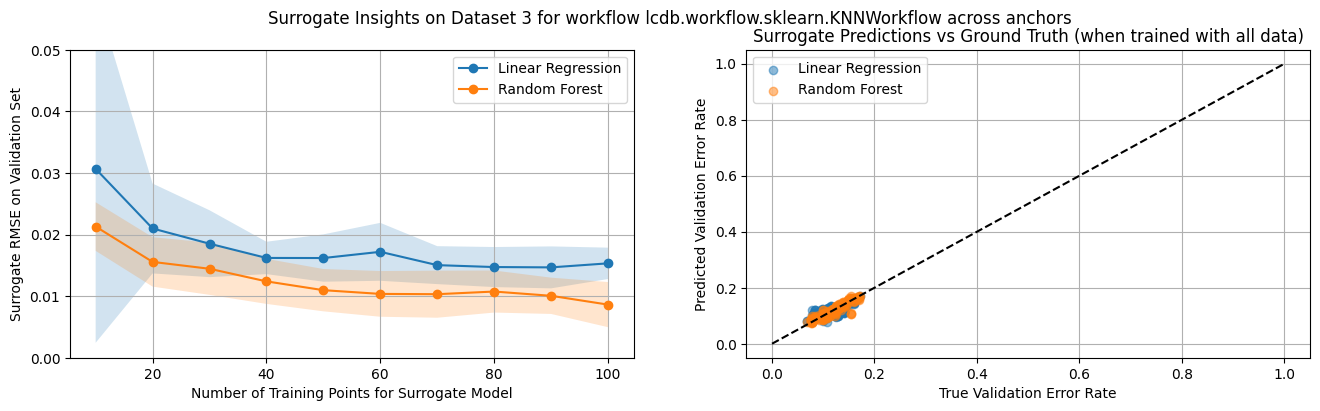

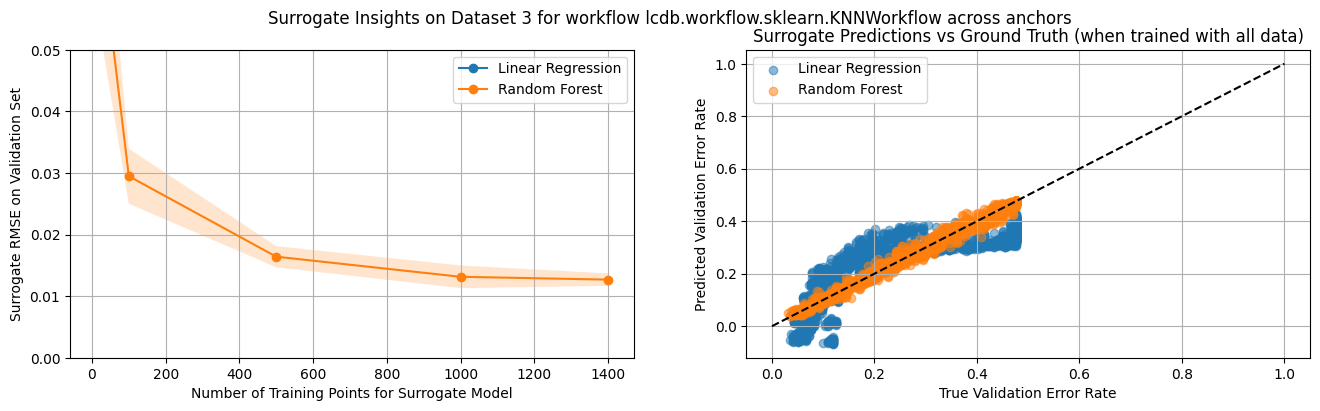

In [37]:
plot_surrogate_learning_success(ground_truth_pairs_per_anchor[0])
plot_surrogate_learning_success(ground_truth_pairs_across_anchors)